In [37]:
import requests
import pandas as pd
import re
import time
from bs4 import BeautifulSoup     
import matplotlib.pyplot as plt
import unicodedata
import os
from tqdm import tqdm


## load unique drug names

In [31]:
def _normalize(s) -> str:
    if s is None:
        return ""
    try:
        s = str(s)
    except Exception:
        return ""
    s = unicodedata.normalize("NFKC", s).lower()
    # allow letters/digits/hyphens; everything else → space
    s = re.sub(r'[^0-9a-z\-]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s


def build_approved_index(approved_list):
    # keep original + normalized for faster matching
    return [(orig, _normalize(orig)) for orig in approved_list]

In [17]:
def plot_drug_count_hist(df):
    # Define non-overlapping bins
    bins = [0, 1, 10, 100, 1000, 5000, float("inf")]
    labels = [
        "1",
        "2–10",
        "11–100",
        "101–1k",
        "1k–5k",
        ">5k"
    ]
    
    # Cut into bins
    df["count_bin"] = pd.cut(df["n_articles"], bins=bins, labels=labels, right=True, include_lowest=True)
    
    # Count how many drugs per bin
    bin_counts = df["count_bin"].value_counts().reindex(labels, fill_value=0)
    
    # --- Print summary ---
    print(bin_counts)
    
    # --- Plot ---
    plt.figure(figsize=(8,5))
    plt.bar(bin_counts.index, bin_counts.values)
    plt.xlabel("Number of articles per drug (binned)")
    plt.ylabel("Number of unique drugs")
    plt.title("Distribution of drug study frequencies")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return bin_counts



In [18]:
terms_path = "out/unique_drug_terms_218510.csv"
terms = pd.read_csv(terms_path)
terms

,Unnamed: 0,drug_term_umls_norm_manual_clean,n_articles
0,23191,Dexamethasone,5865
1,18687,Acetylcysteine,4463
2,23520,Doxorubicin,4411
3,30933,NG-Nitroarginine Methyl Ester,4166
4,36209,Sirolimus,3839
...,...,...,...
218505,89020,diarylaminopropylamine derivative,1
218506,89021,diarylbenzopyrimidine,1
218507,89022,diarylbenzopyrimidine analogues,1
218508,89023,diarylcoumarins,1


count_bin
1         159825
2–10       48044
11–100      9113
101–1k      1427
1k–5k        100
>5k            1
Name: count, dtype: int64


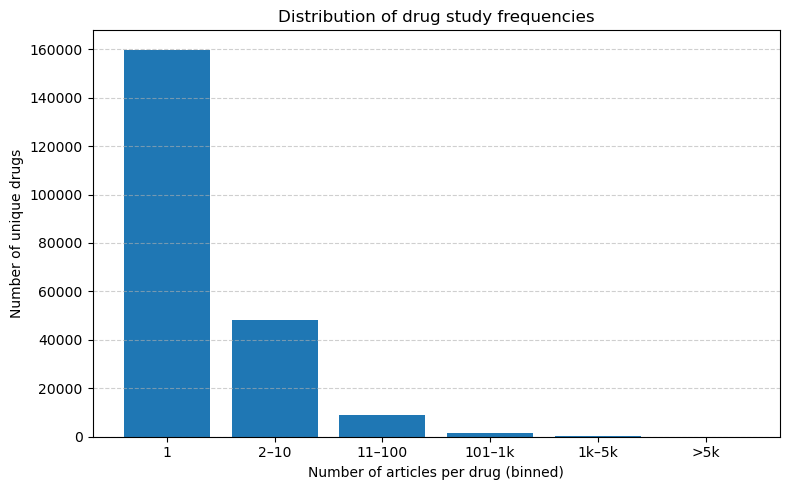

In [19]:
# Usage
bin_counts = plot_drug_count_hist(terms)

In [21]:
terms_common = terms[terms['n_articles']>1]
terms_common

,Unnamed: 0,drug_term_umls_norm_manual_clean,n_articles,count_bin
0,23191,Dexamethasone,5865,>5k
1,18687,Acetylcysteine,4463,1k–5k
2,23520,Doxorubicin,4411,1k–5k
3,30933,NG-Nitroarginine Methyl Ester,4166,1k–5k
4,36209,Sirolimus,3839,1k–5k
...,...,...,...,...
58680,17948,AGN 194310,2,2–10
58681,15622,67cu -,2,2–10
58682,213262,verapamil and diltiazem,2,2–10
58683,17949,AGN 204396,2,2–10


In [22]:
terms_common_list = list(terms_common['drug_term_umls_norm_manual_clean'])

In [32]:
approved_index = build_approved_index(terms_common_list)

In [35]:
approved_index[:5]

[('Dexamethasone', 'dexamethasone'),
 ('Acetylcysteine', 'acetylcysteine'),
 ('Doxorubicin', 'doxorubicin'),
 ('NG-Nitroarginine Methyl Ester', 'ng-nitroarginine methyl ester'),
 ('Sirolimus', 'sirolimus')]

## fetch via FDA API

In [2]:
def first_fda_approval_details(drug):
    q = f'openfda.generic_name:"{drug}"'
    try:
        resp = requests.get(
            "https://api.fda.gov/drug/drugsfda.json",
            params={"search": q, "limit": 100}
        )
        resp.raise_for_status()
    except requests.HTTPError as e:
        if resp.status_code == 404:
            return None
        else:
            raise

    records = resp.json().get("results", [])

    orig_subs = []
    for rec in records:
        for sub in rec.get("submissions", []):
            if sub.get("submission_type") in ("ORIG", "NDA", "BLA"):
                date = pd.to_datetime(sub["submission_status_date"],
                                      format="%Y%m%d",
                                      errors="coerce")
                if pd.notna(date):
                    orig_subs.append({
                        "date": date,
                        "submission": sub,
                        "record": rec
                    })

    if not orig_subs:
        return None

    first = min(orig_subs, key=lambda x: x["date"])
    sub = first["submission"]
    rec = first["record"]
    openfda = rec.get("openfda", {})

    return {
        "generic_name": drug,
        "sponsor_name": rec.get("sponsor_name"),
        "application_number": rec.get("application_number"),
        "submission_type": sub.get("submission_type"),
        "submission_number": sub.get("submission_number"),
        "approval_date": first["date"],
        "indication": rec.get("products", [{}])[0].get("indication"),
        "pharm_class_cs": openfda.get("pharm_class_cs"),
        "pharm_class_epc": openfda.get("pharm_class_epc"),
        "pharm_class_pe": openfda.get("pharm_class_pe"),
        "pharm_class_moa": openfda.get("pharm_class_moa")
    }


In [3]:
first_fda_approval_details("fampridine")

In [4]:
first_fda_approval_details("dalfampridine")

{'generic_name': 'dalfampridine',
 'sponsor_name': 'MERZ',
 'application_number': 'NDA022250',
 'submission_type': 'ORIG',
 'submission_number': '1',
 'approval_date': Timestamp('2010-01-22 00:00:00'),
 'indication': None,
 'pharm_class_cs': None,
 'pharm_class_epc': ['Potassium Channel Blocker [EPC]'],
 'pharm_class_pe': None,
 'pharm_class_moa': ['Potassium Channel Antagonists [MoA]']}

In [ ]:
CHECKPOINT_EVERY = 1000
OUTPUT_PATH = "out/fda_drug_metadata_progress.csv"

# --- Resume if checkpoint exists ---
if os.path.exists(OUTPUT_PATH):
    df_existing = pd.read_csv(OUTPUT_PATH)
    processed = set(df_existing["canonical_drug_name"])
    print(f"🔁 Resuming from checkpoint — {len(processed)} drugs already processed.")
else:
    df_existing = pd.DataFrame()
    processed = set()

records = []

# tqdm progress bar over all drugs
for canonical_drug_name, drug in tqdm(approved_index, desc="Processing drugs"):
    if canonical_drug_name in processed:
        continue  # skip already processed

    details = first_fda_approval_details(drug)

    # Try reversed form if first failed
    if not details:
        drug_parts = drug.split()
        if len(drug_parts) == 2:
            drug_name_reversed = f"{drug_parts[1]} {drug_parts[0]}"
            details = first_fda_approval_details(drug_name_reversed)

    # Extract metadata safely
    approval_date = details.get("approval_date") if details else None
    epc = details.get("pharm_class_epc") if details else None
    moa = details.get("pharm_class_moa") if details else None
    sponsor_name = details.get("sponsor_name") if details else None

    records.append({
        "canonical_drug_name": canonical_drug_name,
        "queried_name": drug,
        "approval_year": approval_date.year if approval_date else None,
        "pharm_class_epc": epc,
        "pharm_class_moa": moa,
        "sponsor_name": sponsor_name
    })

    # Checkpoint every N new records
    if len(records) % CHECKPOINT_EVERY == 0:
        df_new = pd.DataFrame(records)
        df_ckpt = pd.concat([df_existing, df_new], ignore_index=True)
        df_ckpt.drop_duplicates(subset=["canonical_drug_name"], keep="last", inplace=True)
        df_ckpt.to_csv(OUTPUT_PATH, index=False)
        print(f"💾 Checkpoint saved ({len(df_ckpt)} total rows).")
        df_existing = df_ckpt.copy()

# --- Final save ---
df_final = pd.concat([df_existing, pd.DataFrame(records)], ignore_index=True)
df_final.drop_duplicates(subset=["canonical_drug_name"], keep="last", inplace=True)
df_final.to_csv(OUTPUT_PATH, index=False)
print(f"\n✅ Done! Saved full table with {len(df_final)} rows to {OUTPUT_PATH}")

Processing drugs:   2%|▏         | 1000/58685 [14:48<16:48:10,  1.05s/it]

💾 Checkpoint saved (1000 total rows).


Processing drugs:   3%|▎         | 2000/58685 [30:34<12:59:00,  1.21it/s]

💾 Checkpoint saved (2000 total rows).


Processing drugs:   5%|▌         | 3000/58685 [47:09<13:02:03,  1.19it/s] 

...

Processing drugs:  20%|██        | 12000/58685 [3:14:55<14:48:13,  1.14s/it] 

💾 Checkpoint saved (12000 total rows).


Processing drugs:  22%|██▏       | 13000/58685 [3:31:32<13:38:35,  1.08s/it]

💾 Checkpoint saved (13000 total rows).


Processing drugs:  22%|██▏       | 13112/58685 [3:33:21<13:19:49,  1.05s/it]

In [29]:
drug_years

{'Alemtuzumab': 2001,
 'Cladribine': 2000,
 'Fumarate, Dimethyl': 2013,
 'Fampridine': None,
 'Fingolimod': 2010,
 'Acetate, Glatiramer': 1996,
 'beta 1 Interferon': None,
 'Monomethyl fumarate': 2020,
 'Natalizumab': 2004,
 'ocrelizumab': 2017,
 'ofatumumab': 2009,
 'ozanimod': 2020,
 'peginterferon beta-1a': 2014,
 'ponesimod': 2021,
 'riTUXimab': 1997,
 'siponimod': 2019,
 'teriflunomide': 2012}

### Drugs Website

In [41]:
USER_AGENT = (
    "Mozilla/5.0 (compatible; FDAYearScraper/1.0; +your-email-or-repo)"
)

# ----------------------------------------------------------------------
# Low-level page fetcher  →  integer year | None
# ----------------------------------------------------------------------
def _year_from_history_page(slug: str, session: requests.Session) -> int | None:
    """
    Try https://www.drugs.com/history/<slug>.html and pull 'First approved <YEAR>'
    Returns the int YEAR or None if not found / 404 / parse fail.
    """
    url = f"https://www.drugs.com/history/{slug}.html"
    print(f"try {url}")
    try:
        r = session.get(url, headers={"User-Agent": USER_AGENT}, timeout=(5, 15))
        if r.status_code == 404:           # saves a soup parse if the page is absent
            print(f"[ERROR] status_code 404")
            return None
        r.raise_for_status()
    except requests.RequestException:
        print(f"[ERROR] Failed to fetch {url}: {e}")
        return None                        # network error, SSL issue, etc.

    soup = BeautifulSoup(r.text, "html.parser")
    node = soup.find(string=re.compile(r"First approved", re.I))
    if not node:
        return None

    m = re.search(r"\b(\d{4})\b", node)
    return int(m.group(1)) if m else None


# ----------------------------------------------------------------------
# Heuristic slug generator  (very lightweight “slugify”)
# e.g. "Fumarate, Dimethyl" → ["fumarate-dimethyl", "dimethyl-fumarate"]
# ----------------------------------------------------------------------
def _candidate_slugs(drug_name: str) -> list[str]:
    """
    Generate possible Drugs.com history slugs from a drug name.
    Special cases handled (e.g., Fampridine → Dalfampridine).
    """
    # --- special synonyms / redirects ---
    if drug_name.strip().lower() == "fampridine":
        return ["dalfampridine"]

    # --- generic slug building ---
    words = re.sub(r"[^0-9a-zA-Z]+", " ", drug_name).lower().split()
    slugs = ["-".join(words)]

    # if original name had a comma, also try reversed word order
    if "," in drug_name:
        slugs.append("-".join(reversed(words)))

    # de-duplicate while preserving order
    return list(dict.fromkeys(slugs))


# ----------------------------------------------------------------------
# Public helper
# ----------------------------------------------------------------------
def fill_missing_approval_years(data: dict[str, int | None],
                                delay: float = 1.0) -> dict[str, int | None]:
    """
    Mutates and returns `data`, filling any None entries with the scraped year
    (or leaving None if the page/year is not found).
    `delay` pauses N seconds between hits to be polite.
    """
    session = requests.Session()

    for drug, yr in data.items():
        if yr is not None:
            continue                      # already have a year

        for slug in _candidate_slugs(drug):
            got = _year_from_history_page(slug, session)
            if got:
                data[drug] = got
                break                     # stop trying other slugs

        time.sleep(delay)                 # throttle

    return data



In [44]:
drug_years = fill_missing_approval_years(drug_years)

try https://www.drugs.com/history/dalfampridine.html
try https://www.drugs.com/history/beta-1-interferon.html
[ERROR] status_code 404


In [45]:
drug_years

{'Alemtuzumab': 2001,
 'Cladribine': 2000,
 'Fumarate, Dimethyl': 2013,
 'Fampridine': 2010,
 'Fingolimod': 2010,
 'Acetate, Glatiramer': 1996,
 'beta 1 Interferon': None,
 'Monomethyl fumarate': 2020,
 'Natalizumab': 2004,
 'ocrelizumab': 2017,
 'ofatumumab': 2009,
 'ozanimod': 2020,
 'peginterferon beta-1a': 2014,
 'ponesimod': 2021,
 'riTUXimab': 1997,
 'siponimod': 2019,
 'teriflunomide': 2012}

In [50]:
with open("outputs/drug_approval_years_MS.json", "w", encoding="utf-8") as f:
    json.dump(drug_years, f, indent=2, ensure_ascii=False)